# Module 1 Homework 2026

**Student:** Santiago Parada  
**Course:** Stock Markets Analytics Zoomcamp  
**Verified:** 14 September 2026

This notebook answers the six homework questions with reproducible Python code. The calculations use a fixed cutoff of **21 August 2026** where the assignment specifies it.

## TLDR

- **Question 1:** 2025 had the most additions among the complete years from 2020 onward, with **18 current constituents added**. **224** current constituents with known dates had been in the index for more than 20 years by the cutoff.
- **Question 2:** **2 of the 10 non-US indexes** beat the S&P 500 YTD. The counts were also 2 over 3 years, 2 over 5 years and 1 over 10 years.
- **Question 3:** The median correction was **7.99%**, with a median peak-to-trough duration of **40.5 calendar days**.
- **Question 4:** For positive Amazon earnings surprises, the median two-day return was **0.35%**. The correlation with surprise magnitude was **0.33**, a weak positive association in this small sample.
- **Questions 5 and 6:** The proposed capstone is **EnergyRisk Colombia**, a simple next-day electricity spot-price forecast with a rolling-volatility alert, using public XM data.

## Context and methods

### Main assumptions

1. Returns use unadjusted **Close**, as requested.
2. Yahoo Finance treats the `end` date as exclusive. Therefore, `2026-08-22` is used to include the close of 21 August.
3. The index comparison contains 11 tickers: the S&P 500 benchmark plus 10 non-US indexes. The answer is therefore “x out of 10”.
4. A correction runs from an all-time-high close to the minimum close before the next all-time high. Duration means peak to trough, matching the examples in the assignment.
5. Correlation is descriptive and is not interpreted as causation.

### Sources

- [Wikipedia S&P 500 constituents](https://en.wikipedia.org/wiki/List_of_S%26P_500_companies)
- [Yahoo Finance World Indices](https://finance.yahoo.com/world-indices/)
- [yfinance download documentation](https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html)
- [yfinance earnings dates documentation](https://ranaroussi.github.io/yfinance/reference/api/yfinance.Ticker.get_earnings_dates.html)
- [XM API repository and variable catalog](https://github.com/EquipoAnaliticaXM/API_XM)
- [XM Sinergox](https://sinergox.xm.com.co/)

The assignment recommends `yfinance`, and the helper below contains that route. During verification Yahoo rate-limited the package, so `USE_YFINANCE` is set to `False` and the executed notebook uses Yahoo's public chart endpoint. Set it to `True` to try the course's original route.

## Setup

In [1]:
# If needed, run this once in a new environment:
# %pip install pandas numpy matplotlib requests yfinance lxml beautifulsoup4

from io import StringIO
from urllib.parse import quote

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
try:
    import yfinance as yf
except ModuleNotFoundError:
    yf = None
from IPython.display import display

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.2f}".format)

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "blue": "#315B7D",
    "gold": "#C3922E",
    "orange": "#C66A32",
    "gray": "#6B7280",
}

HEADERS = {"User-Agent": "Mozilla/5.0"}
CUTOFF = pd.Timestamp("2026-08-21")
USE_YFINANCE = False  # Change to True when Yahoo permits yfinance requests.

### Yahoo price helpers

In [2]:
def yahoo_chart_close(ticker, start, end):
    # Download one daily closing-price series from Yahoo's chart endpoint.
    start_timestamp = int(pd.Timestamp(start, tz="UTC").timestamp())
    end_timestamp = int(pd.Timestamp(end, tz="UTC").timestamp())
    encoded_ticker = quote(ticker, safe="")
    url = f"https://query1.finance.yahoo.com/v8/finance/chart/{encoded_ticker}"
    params = {
        "period1": start_timestamp,
        "period2": end_timestamp,
        "interval": "1d",
        "events": "history",
    }

    response = requests.get(url, params=params, headers=HEADERS, timeout=45)
    response.raise_for_status()
    result = response.json()["chart"]["result"][0]
    values = result["indicators"]["quote"][0]["close"]
    dates = pd.to_datetime(result["timestamp"], unit="s", utc=True)

    close = pd.Series(values, index=dates, name=ticker, dtype="float64")
    close.index = close.index.tz_convert(None).normalize()
    return close.dropna().sort_index()


def download_one_close(ticker, start, end):
    # Try yfinance first and use the Yahoo chart endpoint as a fallback.
    if USE_YFINANCE and yf is not None:
        try:
            data = yf.download(
                ticker,
                start=start,
                end=end,
                auto_adjust=False,
                progress=False,
                timeout=15,
            )
            if not data.empty:
                close = data["Close"]
                if isinstance(close, pd.DataFrame):
                    close = close.iloc[:, 0]
                close.index = pd.to_datetime(close.index).tz_localize(None).normalize()
                return close.dropna().rename(ticker)
        except Exception:
            pass

    return yahoo_chart_close(ticker, start, end)

## Question 1  S&P 500 additions

We download the current constituent table, convert the addition date to a real datetime and count the years. Because the question asks for a **full year**, 2026 is excluded from the annual comparison.

In [3]:
sp500_url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
response = requests.get(sp500_url, headers=HEADERS, timeout=45)
response.raise_for_status()

companies = pd.read_html(StringIO(response.text))[0]
companies = companies[["Symbol", "Security", "Date added"]].copy()
companies["Date added"] = pd.to_datetime(companies["Date added"], errors="coerce")
companies["Year added"] = companies["Date added"].dt.year

display(companies.head())
print("Rows:", len(companies))
print("Missing addition dates:", companies["Date added"].isna().sum())

,Symbol,Security,Date added,Year added
0,MMM,3M,1957-03-04,1957
1,AOS,A. O. Smith,2017-07-26,2017
2,ABT,Abbott Laboratories,1957-03-04,1957
3,ABBV,AbbVie,2012-12-31,2012
4,ACN,Accenture,2011-07-06,2011


Rows: 503
Missing addition dates: 0


,Current constituents added
Year added,
2020,10
2021,10
2022,15
2023,15
2024,16
2025,18


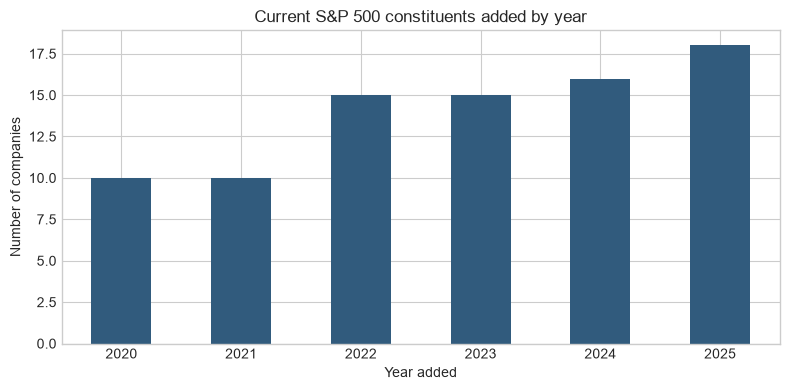

Answer: 2025 had the highest number of additions: 18.
Additional answer: 224 current constituents had been in the index for more than 20 years.


In [4]:
complete_years = companies["Year added"].between(2020, 2025)
additions_by_year = (
    companies.loc[complete_years, "Year added"]
    .value_counts()
    .sort_index()
)

top_year = int(additions_by_year.idxmax())
top_count = int(additions_by_year.max())

twenty_year_threshold = CUTOFF - pd.DateOffset(years=20)
more_than_20_years = int(companies["Date added"].lt(twenty_year_threshold).sum())

display(additions_by_year.rename("Current constituents added").to_frame())

fig, ax = plt.subplots(figsize=(8, 4))
additions_by_year.plot(kind="bar", color=COLORS["blue"], ax=ax)
ax.set_title("Current S&P 500 constituents added by year")
ax.set_xlabel("Year added")
ax.set_ylabel("Number of companies")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print(f"Answer: {top_year} had the highest number of additions: {top_count}.")
print(f"Additional answer: {more_than_20_years} current constituents had been in the index for more than 20 years.")

**Interpretation.** These counts describe companies that are in the index now. They are not a complete historical count of every company ever added, because firms later removed from the index are absent from the current-constituent table.

## Question 2  International index returns

For every period, the return is:

\[
R = 
rac{	ext{final close}}{	ext{initial close}} - 1
\]

Different markets have different holidays, so we use the first and last available observations inside each requested interval.

In [5]:
INDEXES = {
    "United States — S&P 500": "^GSPC",
    "China — Shanghai Composite": "000001.SS",
    "Hong Kong — Hang Seng": "^HSI",
    "Australia — S&P/ASX 200": "^AXJO",
    "India — Nifty 50": "^NSEI",
    "Canada — S&P/TSX Composite": "^GSPTSE",
    "Germany — DAX": "^GDAXI",
    "United Kingdom — FTSE 100": "^FTSE",
    "Japan — Nikkei 225": "^N225",
    "Mexico — IPC": "^MXX",
    "Brazil — Ibovespa": "^BVSP",
}


def download_index_closes(indexes, start, end):
    # Download each index and store its closing-price series in a dictionary.
    prices = {}
    for name, ticker in indexes.items():
        prices[name] = download_one_close(ticker, start, end)
    return prices


def period_return(close, start, end):
    period = close.loc[(close.index >= start) & (close.index <= end)].dropna()
    if len(period) < 2:
        return np.nan
    return period.iloc[-1] / period.iloc[0] - 1


index_prices = download_index_closes(INDEXES, "2016-08-20", "2026-08-22")

In [6]:
return_rows = []

for index_name in INDEXES:
    close = index_prices[index_name]
    return_rows.append({
        "Index": index_name,
        "YTD 2026": period_return(close, pd.Timestamp("2026-01-01"), CUTOFF),
        "3 years": period_return(close, CUTOFF - pd.DateOffset(years=3), CUTOFF),
        "5 years": period_return(close, CUTOFF - pd.DateOffset(years=5), CUTOFF),
        "10 years": period_return(close, CUTOFF - pd.DateOffset(years=10), CUTOFF),
    })

index_returns = pd.DataFrame(return_rows).set_index("Index")
index_returns_percent = index_returns.mul(100)

sp500_returns = index_returns.loc["United States — S&P 500"]
better_than_sp500 = (
    index_returns
    .drop(index="United States — S&P 500")
    .gt(sp500_returns)
    .sum()
    .astype(int)
)

display(index_returns_percent.round(2))
display(better_than_sp500.rename("Indexes beating S&P 500").to_frame())

,YTD 2026,3 years,5 years,10 years
Index,,,,
United States — S&P 500,11.90,74.43,71.32,251.61
China — Shanghai Composite,-2.94,26.26,12.31,26.59
Hong Kong — Hang Seng,-1.25,47.59,3.58,13.09
Australia — S&P/ASX 200,3.79,27.31,20.95,64.26
India — Nifty 50,-7.25,25.05,47.01,181.05
Canada — S&P/TSX Composite,14.86,85.09,78.83,148.30
Germany — DAX,6.51,67.51,64.87,149.05
United Kingdom — FTSE 100,8.70,49.03,52.15,58.40
Japan — Nikkei 225,27.36,109.14,140.11,297.73


,Indexes beating S&P 500
YTD 2026,2
3 years,2
5 years,2
10 years,1


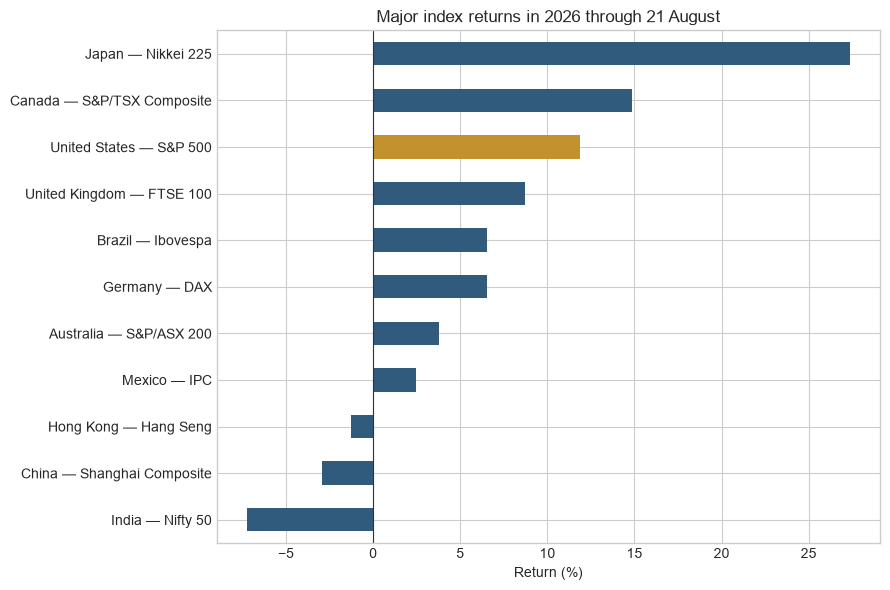

Main answer: 2 of 10 non-US indexes beat the S&P 500 YTD.
Additional answers:
- 3 years: 2 of 10
- 5 years: 2 of 10
- 10 years: 1 of 10


In [7]:
ytd = index_returns_percent["YTD 2026"].sort_values()
bar_colors = [
    COLORS["gold"] if name == "United States — S&P 500" else COLORS["blue"]
    for name in ytd.index
]

fig, ax = plt.subplots(figsize=(9, 6))
ytd.plot(kind="barh", color=bar_colors, ax=ax)
ax.axvline(0, color="#333333", linewidth=0.8)
ax.set_title("Major index returns in 2026 through 21 August")
ax.set_xlabel("Return (%)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print(f"Main answer: {better_than_sp500['YTD 2026']} of 10 non-US indexes beat the S&P 500 YTD.")
print("Additional answers:")
for period in ["3 years", "5 years", "10 years"]:
    print(f"- {period}: {better_than_sp500[period]} of 10")

**Interpretation.** Only Canada and Japan beat the S&P 500 during the 2026 YTD period. The counts do not show a broad and persistent international advantage: two indexes beat the US over three and five years, and only Japan did so over ten years. Currency effects are ignored as requested.

## Question 3  S&P 500 corrections

The algorithm finds every new all-time-high close. Between one record high and the next, it finds the minimum close and measures the fall from the original peak. Only falls of at least 5% are retained.

In [8]:
def find_corrections(close, minimum_drawdown=5):
    close = close.dropna().sort_index()
    previous_high = close.cummax().shift(1, fill_value=-np.inf)
    record_dates = close.index[close.gt(previous_high)]

    episodes = []
    for peak_date, next_high_date in zip(record_dates[:-1], record_dates[1:]):
        window = close.loc[peak_date:next_high_date]
        trough_date = window.idxmin()
        peak_price = close.loc[peak_date]
        trough_price = close.loc[trough_date]
        drawdown = (peak_price - trough_price) / peak_price * 100

        episodes.append({
            "Peak date": peak_date,
            "Trough date": trough_date,
            "Next high date": next_high_date,
            "Drawdown (%)": drawdown,
            "Duration (days)": (trough_date - peak_date).days,
        })

    episodes = pd.DataFrame(episodes)
    return episodes.loc[episodes["Drawdown (%)"] >= minimum_drawdown].copy()


sp500_close = download_one_close("^GSPC", "1950-01-01", "2026-09-15")
corrections = find_corrections(sp500_close)

correction_percentiles = corrections[["Drawdown (%)", "Duration (days)"]].quantile(
    [0.25, 0.50, 0.75]
)
correction_percentiles.index = ["25th percentile", "Median", "75th percentile"]

display(correction_percentiles.round(2))
print("Number of corrections:", len(corrections))

,Drawdown (%),Duration (days)
25th percentile,6.23,22.00
Median,7.99,40.50
75th percentile,14.02,86.25


Number of corrections: 74


,Peak date,Trough date,Drawdown (%),Duration (days)
1040,2007-10-09,2009-03-09,56.78,517
1031,2000-03-24,2002-10-09,49.15,929
528,1973-01-11,1974-10-03,48.20,630
493,1968-11-29,1970-05-26,36.06,543
1295,2020-02-19,2020-03-23,33.92,33
704,1987-08-25,1987-12-04,33.51,101
327,1961-12-12,1962-06-26,27.97,196
552,1980-11-28,1982-08-12,27.11,622
1386,2022-01-03,2022-10-12,25.43,282
446,1966-02-09,1966-10-07,22.18,240


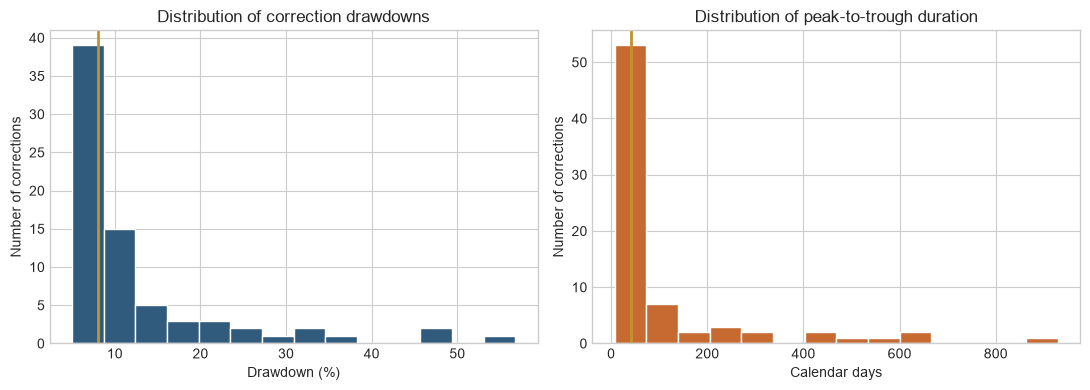

Main answer: the median significant correction was 7.99%.
The median peak-to-trough duration was 40.5 calendar days.


In [9]:
largest_corrections = corrections.nlargest(10, "Drawdown (%)")
display(
    largest_corrections[
        ["Peak date", "Trough date", "Drawdown (%)", "Duration (days)"]
    ].round({"Drawdown (%)": 2})
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(corrections["Drawdown (%)"], bins=14, color=COLORS["blue"], edgecolor="white")
axes[0].axvline(corrections["Drawdown (%)"].median(), color=COLORS["gold"], linewidth=2)
axes[0].set_title("Distribution of correction drawdowns")
axes[0].set_xlabel("Drawdown (%)")
axes[0].set_ylabel("Number of corrections")

axes[1].hist(corrections["Duration (days)"], bins=14, color=COLORS["orange"], edgecolor="white")
axes[1].axvline(corrections["Duration (days)"].median(), color=COLORS["gold"], linewidth=2)
axes[1].set_title("Distribution of peak-to-trough duration")
axes[1].set_xlabel("Calendar days")
axes[1].set_ylabel("Number of corrections")

plt.tight_layout()
plt.show()

median_drawdown = correction_percentiles.loc["Median", "Drawdown (%)"]
median_duration = correction_percentiles.loc["Median", "Duration (days)"]
print(f"Main answer: the median significant correction was {median_drawdown:.2f}%.")
print(f"The median peak-to-trough duration was {median_duration:.1f} calendar days.")

**Validation.** The ten largest episodes reproduce the dates and approximate drawdowns supplied in the homework hint. That is an important reasonableness check on the event definition.

## Question 4  Amazon earnings surprises

The requested return uses three consecutive trading days. If the earnings date is Day 2, the calculation is:

\[
R_{2d} = 
rac{	ext{Close on Day 3}}{	ext{Close on Day 1}} - 1
\]

The first function tries `get_earnings_dates(limit=25)`. A fallback uses Yahoo's current calendar service because the HTML endpoint used by some `yfinance` versions can be rate-limited or changed by Yahoo.

In [10]:
def yahoo_earnings_fallback(ticker, start, end, size=25):
    session = requests.Session()
    session.headers.update(HEADERS)
    session.get("https://fc.yahoo.com", timeout=30)
    crumb = session.get(
        "https://query1.finance.yahoo.com/v1/test/getcrumb", timeout=30
    ).text

    fields = [
        "ticker", "companyshortname", "eventname", "startdatetime",
        "startdatetimetype", "epsestimate", "epsactual", "epssurprisepct",
        "timeZoneShortName", "gmtOffsetMilliSeconds",
    ]
    payload = {
        "sortType": "DESC",
        "entityIdType": "sp_earnings",
        "sortField": "startdatetime",
        "includeFields": fields,
        "query": {
            "operator": "and",
            "operands": [
                {"operator": "eq", "operands": ["ticker", ticker]},
                {"operator": "gte", "operands": ["startdatetime", start]},
                {"operator": "lt", "operands": ["startdatetime", end]},
                {"operator": "or", "operands": [
                    {"operator": "eq", "operands": ["eventtype", "EAD"]},
                    {"operator": "eq", "operands": ["eventtype", "ERA"]},
                ]},
            ],
        },
        "offset": 0,
        "size": size,
    }

    response = session.post(
        "https://query1.finance.yahoo.com/v1/finance/visualization",
        params={"lang": "en-US", "region": "US", "crumb": crumb},
        json=payload,
        timeout=45,
    )
    response.raise_for_status()
    document = response.json()["finance"]["result"][0]["documents"][0]
    columns = [column["id"] for column in document["columns"]]
    earnings = pd.DataFrame(document["rows"], columns=columns)
    earnings["date"] = pd.to_datetime(earnings["startdatetime"], utc=True).dt.tz_localize(None).dt.normalize()
    return earnings.sort_values("date", ascending=False).reset_index(drop=True)


def download_earnings_dates(ticker):
    if USE_YFINANCE and yf is not None:
        try:
            raw = yf.Ticker(ticker).get_earnings_dates(limit=25)
            if raw is not None and len(raw) >= 24:
                earnings = raw.reset_index()
                date_column = earnings.columns[0]
                earnings = earnings.rename(columns={
                    date_column: "date",
                    "Reported EPS": "epsactual",
                    "Surprise(%)": "epssurprisepct",
                    "Surprise (%)": "epssurprisepct",
                })
                earnings["date"] = pd.to_datetime(earnings["date"], utc=True).dt.tz_localize(None).dt.normalize()
                return earnings
        except Exception:
            pass

    return yahoo_earnings_fallback(ticker, "2020-10-29", "2027-01-01", size=25)


earnings = download_earnings_dates("AMZN")
print("Earnings entries downloaded:", len(earnings))
display(earnings[["date", "epsestimate", "epsactual", "epssurprisepct"]].head())

Earnings entries downloaded: 25


,date,epsestimate,epsactual,epssurprisepct
0,2026-10-29,1.95,NaN,NaN
1,2026-07-30,1.83,5.75,215.02
2,2026-04-29,1.64,2.78,69.02
3,2026-02-05,1.95,1.95,0.22
4,2025-10-30,1.56,1.95,25.20


In [11]:
amzn_close = download_one_close("AMZN", "2020-10-01", "2026-08-05")
realized_earnings = earnings.dropna(subset=["epsactual", "epssurprisepct"]).copy()

reaction_rows = []

for _, event in realized_earnings.iterrows():
    event_date = event["date"]
    position = amzn_close.index.get_indexer([event_date])[0]

    if position <= 0 or position >= len(amzn_close) - 1:
        continue

    previous_date = amzn_close.index[position - 1]
    next_date = amzn_close.index[position + 1]
    two_day_return = amzn_close.iloc[position + 1] / amzn_close.iloc[position - 1] - 1

    reaction_rows.append({
        "Earnings date": event_date,
        "Previous trading day": previous_date,
        "Next trading day": next_date,
        "Surprise (%)": float(event["epssurprisepct"]),
        "2-day return (%)": two_day_return * 100,
    })

earnings_reactions = pd.DataFrame(reaction_rows).sort_values("Earnings date")
positive_surprises = earnings_reactions.loc[earnings_reactions["Surprise (%)"] > 0].copy()

median_positive_return = positive_surprises["2-day return (%)"].median()
positive_correlation = positive_surprises[["Surprise (%)", "2-day return (%)"]].corr().iloc[0, 1]
all_events_correlation = earnings_reactions[["Surprise (%)", "2-day return (%)"]].corr().iloc[0, 1]

display(
    earnings_reactions.round({
        "Surprise (%)": 2,
        "2-day return (%)": 2,
    })
)
print(f"Positive surprises: {len(positive_surprises)}")
print(f"Main answer — median 2-day return: {median_positive_return:.2f}%")
print(f"Correlation among positive surprises: {positive_correlation:.2f}")
print(f"Correlation among all completed events: {all_events_correlation:.2f}")

,Earnings date,Previous trading day,Next trading day,Surprise (%),2-day return (%)
23,2020-10-29,2020-10-28,2020-10-30,64.25,-4.00
22,2021-02-02,2021-02-01,2021-02-03,100.10,-0.91
21,2021-04-29,2021-04-28,2021-04-30,67.30,0.26
20,2021-07-29,2021-07-28,2021-07-30,23.06,-8.34
19,2021-10-28,2021-10-27,2021-10-29,-31.21,-0.59
18,2022-02-03,2022-02-02,2022-02-04,657.12,4.67
17,2022-04-28,2022-04-27,2022-04-29,-190.58,-10.05
16,2022-07-28,2022-07-27,2022-07-29,-273.30,11.56
15,2022-10-27,2022-10-26,2022-10-28,35.53,-10.59
14,2023-02-02,2023-02-01,2023-02-03,-82.20,-1.67


Positive surprises: 20
Main answer — median 2-day return: 0.35%
Correlation among positive surprises: 0.33
Correlation among all completed events: 0.22


,count,median,mean
Market regime,,,
Bear,3,3.01,-0.78
Bull,17,0.26,0.68


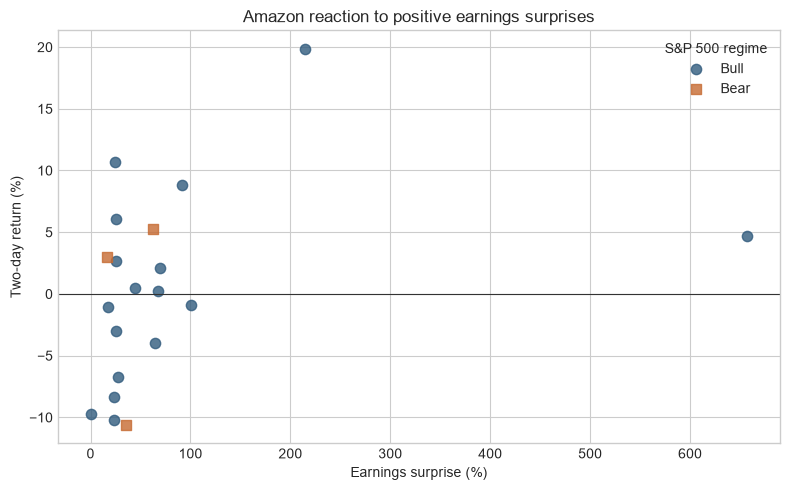

In [12]:
# Additional: classify each event using the S&P 500 versus its 200-day moving average.
sp500_sma_200 = sp500_close.rolling(200).mean()

def market_regime(event_date):
    if sp500_close.loc[event_date] >= sp500_sma_200.loc[event_date]:
        return "Bull"
    return "Bear"

positive_surprises["Market regime"] = positive_surprises["Earnings date"].map(market_regime)
regime_summary = (
    positive_surprises.groupby("Market regime")["2-day return (%)"]
    .agg(["count", "median", "mean"])
)
display(regime_summary.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
for regime, marker, color in [("Bull", "o", COLORS["blue"]), ("Bear", "s", COLORS["orange"])]:
    sample = positive_surprises.loc[positive_surprises["Market regime"] == regime]
    ax.scatter(
        sample["Surprise (%)"],
        sample["2-day return (%)"],
        label=regime,
        marker=marker,
        color=color,
        s=55,
        alpha=0.8,
    )

ax.axhline(0, color="#333333", linewidth=0.8)
ax.set_title("Amazon reaction to positive earnings surprises")
ax.set_xlabel("Earnings surprise (%)")
ax.set_ylabel("Two-day return (%)")
ax.legend(title="S&P 500 regime")
plt.tight_layout()
plt.show()

**Interpretation.** The positive correlation is weak and is influenced by a few very large surprises. The bull/bear comparison is especially uncertain because only three positive-surprise observations occurred in the bear-market group. The results do not establish that larger surprises cause larger returns.

## Question 5  Capstone proposal

### EnergyRisk Colombia  Electricity spot price forecast

I would like to build a simple machine-learning project to forecast the next-day average electricity spot price in Colombia and identify periods of unusually high volatility. The project will use public data from XM, the operator and market administrator of Colombia's interconnected electricity system.

The main prediction target will be the next day's average national spot price in COP/kWh. Explanatory variables will include recent spot prices, electricity demand, useful reservoir volume and hydrological inflows. Hourly observations will be aggregated into daily data to keep the first version simple and interpretable.

I will compare the model against basic benchmarks such as the previous day's price and a seven-day moving average. A linear regression and one tree-based regression model may be evaluated using time-based train and test periods. High-volatility periods will be identified using the rolling standard deviation of daily prices.

The project could help electricity retailers and large consumers understand short-term purchasing risk. It is intended as an analytical prototype rather than a trading or production forecasting system.

## Question 6  Additional EnergyRisk Colombia metrics

This exploratory example downloads 31 days ending on the homework cutoff. That is sufficient to demonstrate the request, cleaning, merging and exploration workflow without building the full capstone pipeline.

| Metric | XM code | Why it is useful |
|---|---|---|
| Weighted national spot price | `PPPrecBolsNaci` | Prediction target and basis for volatility |
| Real electricity demand | `DemaReal` | Measures consumption pressure on the system |
| Useful reservoir volume | `PorcVoluUtilDiar` | Describes available hydroelectric storage |
| Hydrological energy inflows | `AporEner` | Measures recent water-energy arrivals |

In [13]:
XM_START = "2026-07-22"
XM_END = "2026-08-21"


def xm_request(metric, endpoint, start=XM_START, end=XM_END):
    # Request one system-level metric from the public XM API.
    payload = {
        "MetricId": metric,
        "StartDate": start,
        "EndDate": end,
        "Entity": "Sistema",
    }
    url = f"https://servapibi.xm.com.co/{endpoint}"
    response = requests.post(url, json=payload, timeout=45)
    response.raise_for_status()
    return response.json()


def parse_daily_metric(response, column_name):
    rows = []
    for item in response["Items"]:
        value = item["DailyEntities"][0]["Value"]
        rows.append({"Date": item["Date"], column_name: float(value)})
    return pd.DataFrame(rows)


def parse_hourly_metric(response, column_name):
    rows = []
    for item in response["Items"]:
        hourly_values = item["HourlyEntities"][0]["Values"]
        for hour in range(1, 25):
            rows.append({
                "Date": item["Date"],
                "Hour": hour,
                column_name: float(hourly_values[f"Hour{hour:02d}"]),
            })
    return pd.DataFrame(rows)

In [14]:
# Download the four series.
spot_price = parse_daily_metric(
    xm_request("PPPrecBolsNaci", "daily"),
    "Spot price (COP/kWh)",
)

reservoir = parse_daily_metric(
    xm_request("PorcVoluUtilDiar", "daily"),
    "Reservoir useful volume (%)",
)
reservoir["Reservoir useful volume (%)"] *= 100

inflows = parse_daily_metric(
    xm_request("AporEner", "daily"),
    "Hydrological inflows (GWh)",
)
inflows["Hydrological inflows (GWh)"] /= 1_000_000

demand_hourly = parse_hourly_metric(
    xm_request("DemaReal", "hourly"),
    "Demand (GWh)",
)
demand = demand_hourly.groupby("Date", as_index=False)["Demand (GWh)"].sum()
demand["Demand (GWh)"] /= 1_000_000

In [15]:
energy_data = (
    spot_price
    .merge(reservoir, on="Date", validate="one_to_one")
    .merge(inflows, on="Date", validate="one_to_one")
    .merge(demand, on="Date", validate="one_to_one")
)
energy_data["Date"] = pd.to_datetime(energy_data["Date"])
energy_data = energy_data.set_index("Date").sort_index()

energy_data["7-day price volatility"] = (
    energy_data["Spot price (COP/kWh)"].rolling(7).std()
)
volatility_threshold = energy_data["7-day price volatility"].quantile(0.90)
energy_data["High volatility"] = (
    energy_data["7-day price volatility"] > volatility_threshold
)

print("Shape:", energy_data.shape)
display(energy_data.head().round(2))
display(energy_data.isna().sum().rename("Missing values").to_frame())
display(energy_data.drop(columns="High volatility").describe().T.round(2))

Shape: (31, 6)


,Spot price (COP/kWh),Reservoir useful volume (%),Hydrological inflows (GWh),Demand (GWh),7-day price volatility,High volatility
Date,,,,,,
2026-07-22,949.29,79.31,156.55,251.15,NaN,False
2026-07-23,963.34,80.18,400.90,246.79,NaN,False
2026-07-24,851.72,80.49,296.53,248.09,NaN,False
2026-07-25,681.78,80.58,171.47,240.83,NaN,False
2026-07-26,569.23,80.82,199.80,219.66,NaN,False


,Missing values
Spot price (COP/kWh),0
Reservoir useful volume (%),0
Hydrological inflows (GWh),0
Demand (GWh),0
7-day price volatility,6
High volatility,0


,count,mean,std,min,25%,50%,75%,max
Spot price (COP/kWh),31.00,902.68,131.13,569.23,805.65,963.34,1005.19,1031.86
Reservoir useful volume (%),31.00,79.28,0.91,77.65,78.76,79.22,80.09,80.82
Hydrological inflows (GWh),31.00,167.28,72.64,103.83,126.79,148.16,174.24,400.90
Demand (GWh),31.00,245.22,12.88,217.83,239.35,251.15,254.57,261.37
7-day price volatility,25.00,83.14,51.75,5.66,29.95,81.58,130.87,176.05


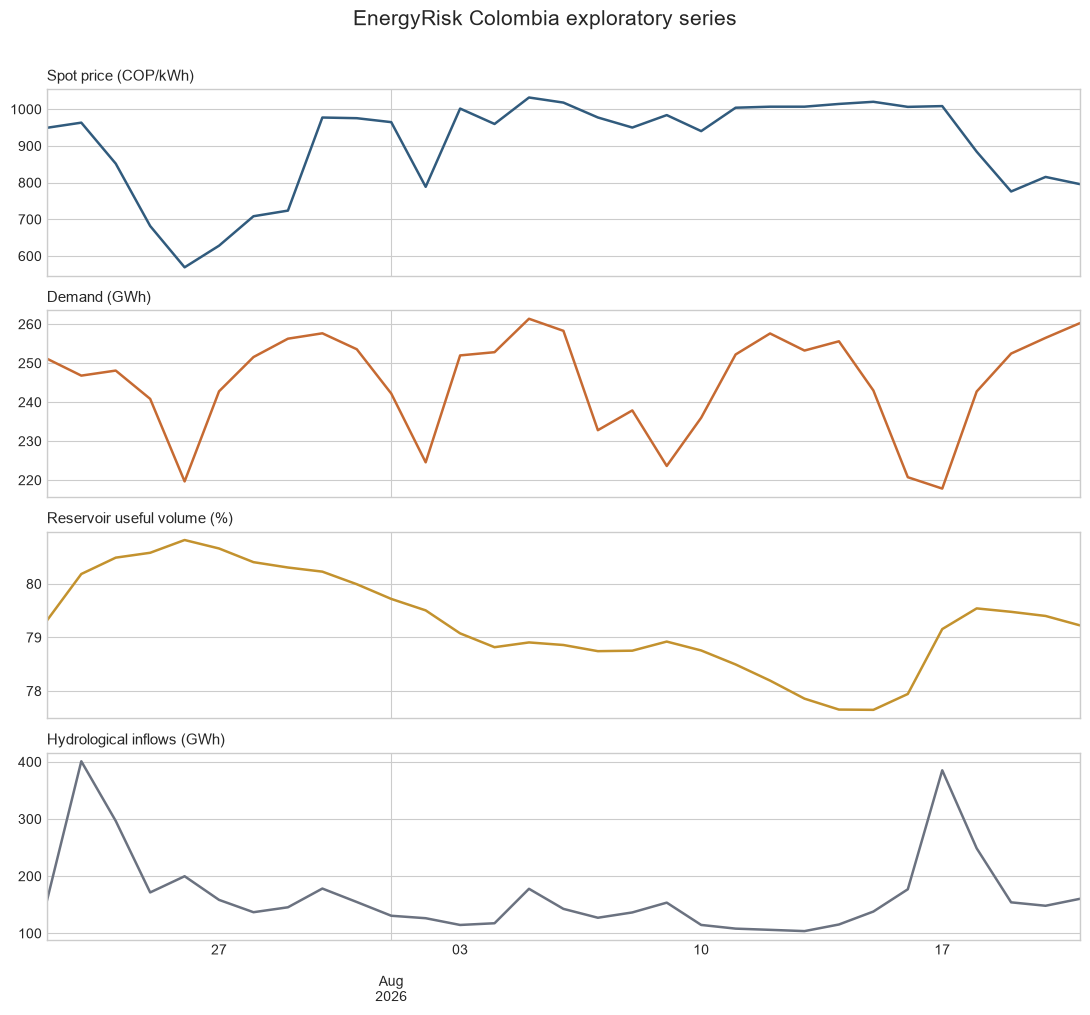

,Spot price (COP/kWh),Reservoir useful volume (%),Hydrological inflows (GWh),Demand (GWh),7-day price volatility
Spot price (COP/kWh),1.00,-0.73,-0.03,0.14,-0.51
Reservoir useful volume (%),-0.73,1.00,0.38,-0.04,0.78
Hydrological inflows (GWh),-0.03,0.38,1.00,-0.28,-0.24
Demand (GWh),0.14,-0.04,-0.28,1.00,0.32
7-day price volatility,-0.51,0.78,-0.24,0.32,1.00


90th-percentile volatility threshold: 152.95 COP/kWh
High-volatility days in the sample: 3


In [16]:
plot_columns = [
    "Spot price (COP/kWh)",
    "Demand (GWh)",
    "Reservoir useful volume (%)",
    "Hydrological inflows (GWh)",
]
plot_colors = [COLORS["blue"], COLORS["orange"], COLORS["gold"], COLORS["gray"]]

fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)
for column, color, ax in zip(plot_columns, plot_colors, axes):
    energy_data[column].plot(ax=ax, color=color, linewidth=1.8)
    ax.set_title(column, loc="left", fontsize=11)
    ax.set_xlabel("")

fig.suptitle("EnergyRisk Colombia exploratory series", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

correlations = energy_data.drop(columns="High volatility").corr()
display(correlations.round(2))

print(f"90th-percentile volatility threshold: {volatility_threshold:.2f} COP/kWh")
print("High-volatility days in the sample:", int(energy_data["High volatility"].sum()))

### Question 6 submission text

I identified four additional time series from XM's Sinergox platform that could be valuable for EnergyRisk Colombia.

**National spot price** is the prediction target. The daily values can also be used to calculate rolling volatility. **Electricity demand** represents pressure from consumption and may help explain short-term price movements. **Useful reservoir volume** describes the state of hydroelectric storage, which is important in Colombia's hydro-dependent system. **Hydrological inflows** measure recent water-energy arrivals and may provide information about changing hydro conditions.

The series were retrieved from XM's public API with Python `requests`. Hourly demand was summed into daily GWh, while the remaining variables were already daily. The tables were converted to a common date index and merged with pandas. I then inspected missing values, descriptive statistics, time-series plots and correlations.

The correlations are exploratory. They do not prove that demand or hydrology causes a price change. A full capstone would expand the history, add lagged variables and evaluate forecasts with chronological validation.

## Final answers for the submission form

1. **2025**, with **18** additions among current constituents. Additional: **224** had been in the index for more than 20 years.
2. **2 of 10** non-US indexes beat the S&P 500 YTD. Additional: **2** over 3 years, **2** over 5 years and **1** over 10 years.
3. Median drawdown: **7.99%**. Duration percentiles: **22**, **40.5** and **86.25** days. Drawdown percentiles: **6.23%**, **7.99%** and **14.02%**.
4. Median two-day return after positive AMZN earnings surprises: **0.35%**. Correlation with positive-surprise magnitude: **0.33**.
5. **EnergyRisk Colombia:** next-day Colombian electricity spot-price forecasting and high-volatility detection.
6. Additional XM series: weighted spot price, real demand, useful reservoir volume and hydrological energy inflows.